In [4]:
import torch
import random
import math
import torch.nn as nn
import networkx as nx
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import time
import copy
#from pyunicorn.timeseries import RecurrenceNetwork
import psutil
import os

from torchviz import make_dot
import torch

torch.autograd.set_detect_anomaly(False)



In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "3"
os.environ["MKL_NUM_THREADS"] = "3"
os.environ["OPENBLAS_NUM_THREADS"] = "3"

import torch
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [ ]:
# node level pipeline graphs
# HYPERPARAMETERS:
#  1. Number of neighbourhood layers to be considered for encoder model
# embedding dim of the letent space
#  2. defining the neural network architecture for node emb --- num_layers?

class KhopNodefeatures(nn.Module):
    def __init__(self, feature_dim, K):
        super().__init__()
        self.K = K
        self.feature_dim = feature_dim
        self.W = nn.ParameterList([nn.Parameter(torch.randn(feature_dim, feature_dim)) for _ in range(K)])
        self.A = nn.Parameter(torch.randn(feature_dim, feature_dim))

    def forward(self, neigh_list, node_features):
        device = node_features.device
        num_nodes = node_features.shape[0]

        neigh_len = torch.tensor([len(neigh) for neigh in neigh_list], dtype=torch.long, device=device)
        neigh_list_tensor = torch.tensor([j for neigh in neigh_list for j in neigh], dtype=torch.long, device=device)  #concatinated tensor
        node_corresp = torch.repeat_interleave(torch.arange(num_nodes, device=device), neigh_len)

        H = [node_features @ self.W[0]]
        for k in range(1, self.K):
            prev_H = H[-1]
            node_trans = node_features @ self.W[k]

            if neigh_list_tensor.numel() > 0:
                neigh_emb = prev_H[neigh_list_tensor] @ self.A
                neigh_sum = torch.zeros(num_nodes, self.feature_dim, dtype=node_features.dtype, device=device)
                neigh_sum.index_add_(0, node_corresp, neigh_emb)
                valid_nodes = neigh_len > 0
                current_H = node_trans.clone()  # separate memory
                neigh_mean = neigh_sum[valid_nodes] / neigh_len[valid_nodes].to(node_features.dtype).unsqueeze(1)
                current_H[valid_nodes] = node_trans[valid_nodes] * neigh_mean
            else:
                current_H = node_trans

            H.append(current_H)

        return torch.stack(H, dim=1)
class NodeLatentEncoder(nn.Module): 
    def __init__(self, K, feature_dim, latent_dim, hidden_dim, num_layers):
        # inputs are 1. K, feature_dim, latebtdim, hidden_dim 
        # if using multiple layers and the number of layers
        # outputs 1. nonlinear transformed 
        # K hop node representations ( dim is the dim of feature vector)
        # 2. u matrix (num_nodes, latent_dim)
        # 3. sigma matrix (num nodes, latent_dim)
        super().__init__()
        self.K = K
        self.feature_dim = feature_dim
        # Nonlinear transform from (K x f) -> f
        self.node_transform = nn.Sequential(
            nn.Linear(K * feature_dim, feature_dim)
        )
        # Build MLPs for mu and sigma
        self.mu_mlp = self.build_mlp_mu(feature_dim, hidden_dim, latent_dim, num_layers)
        self.logvar_mlp = self.build_mlp_sig(feature_dim, hidden_dim, latent_dim, num_layers)

    def build_mlp_mu(self, input_dim, hidden_dim, output_dim, num_layers):
        layers = []
        dim = input_dim
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.ReLU())
            dim = hidden_dim
        layers.append(nn.Linear(dim, output_dim))
        return nn.Sequential(*layers)

    def build_mlp_sig(self, input_dim, hidden_dim, output_dim, num_layers):
        layers = []
        dim = input_dim
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.ReLU())
            dim = hidden_dim
        layers.append(nn.Linear(dim, output_dim))
        return nn.Sequential(*layers)

    def forward(self, H):
        """
        H: (num_nodes, K, feature_dim)
        """
        num_nodes = H.shape[0]
        H_flat = H.reshape(num_nodes, -1)
        node_repr = self.node_transform(H_flat)
        # latent mean and variance
        mu = self.mu_mlp(node_repr)
        #mu = F.tanh(mu) # so that the embeddings are within -1,1 box.
        logvar = self.logvar_mlp(node_repr)
        return mu, torch.nn.functional.softplus(logvar), node_repr  # for positive sigma
class Empirical_Prob_edges(nn.Module):
    # input are the two latent vectors.
    # take the hidden_dim as the latant_dim
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        
        self.mlp_mu = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.mlp_sigma = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.mlp_score = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) 
        )
    def forward(self, z_u, z_v,s_u,s_v):
        # concatenate node embeddings
        mu = z_u+z_v #dim = -1 supports for batches
        sig = s_u+s_v
        score = self.mlp_score(torch.cat([self.mlp_mu(mu),self.mlp_sigma(sig)],dim = -1))
        score = F.softplus(score)
        return score.squeeze(-1)
class Effective_Prob_edges(nn.Module):
    # input are the two latent vectors.
    # take the hidden_dim as the latant_dim
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        
        self.mlp_mu = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.mlp_sigma = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.mlp_score = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) 
        )
    def forward(self, z_u, z_v,s_u,s_v):
        # concatenate node embeddings
        mu = z_u+z_v #dim = -1 supports for batches
        sig = s_u+s_v
        score = self.mlp_score(torch.cat([self.mlp_mu(mu),self.mlp_sigma(sig)],dim = -1))
        # print('raw_score')
        # print(score)
        score = F.softplus(score)
        return score.squeeze(-1)
class BatchedEffectiveProbEdges(nn.Module):
    def __init__(self, num_models, latent_dim, hidden_dim):
        super().__init__()

        self.num_models = num_models
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim

        self.mu_w1 = nn.Parameter(torch.empty(num_models, hidden_dim, latent_dim))
        self.mu_b1 = nn.Parameter(torch.empty(num_models, hidden_dim))
        self.mu_w2 = nn.Parameter(torch.empty(num_models, hidden_dim, hidden_dim))
        self.mu_b2 = nn.Parameter(torch.empty(num_models, hidden_dim))
        self.mu_w3 = nn.Parameter(torch.empty(num_models, hidden_dim, hidden_dim))
        self.mu_b3 = nn.Parameter(torch.empty(num_models, hidden_dim))

        self.sigma_w1 = nn.Parameter(torch.empty(num_models, hidden_dim, latent_dim))
        self.sigma_b1 = nn.Parameter(torch.empty(num_models, hidden_dim))
        self.sigma_w2 = nn.Parameter(torch.empty(num_models, hidden_dim, hidden_dim))
        self.sigma_b2 = nn.Parameter(torch.empty(num_models, hidden_dim))
        self.sigma_w3 = nn.Parameter(torch.empty(num_models, hidden_dim, hidden_dim))
        self.sigma_b3 = nn.Parameter(torch.empty(num_models, hidden_dim))

        self.score_w1 = nn.Parameter(torch.empty(num_models, hidden_dim, 2 * hidden_dim))
        self.score_b1 = nn.Parameter(torch.empty(num_models, hidden_dim))
        self.score_w2 = nn.Parameter(torch.empty(num_models, hidden_dim, hidden_dim))
        self.score_b2 = nn.Parameter(torch.empty(num_models, hidden_dim))
        self.score_w3 = nn.Parameter(torch.empty(num_models, 1, hidden_dim))
        self.score_b3 = nn.Parameter(torch.empty(num_models, 1))

        for model_index in range(num_models):
            nn.init.kaiming_uniform_(self.mu_w1[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.mu_w2[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.mu_w3[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.sigma_w1[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.sigma_w2[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.sigma_w3[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.score_w1[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.score_w2[model_index], a=5 ** 0.5)
            nn.init.kaiming_uniform_(self.score_w3[model_index], a=5 ** 0.5)

            nn.init.uniform_(self.mu_b1[model_index], -latent_dim ** -0.5, latent_dim ** -0.5)
            nn.init.uniform_(self.mu_b2[model_index], -hidden_dim ** -0.5, hidden_dim ** -0.5)
            nn.init.uniform_(self.mu_b3[model_index], -hidden_dim ** -0.5, hidden_dim ** -0.5)
            nn.init.uniform_(self.sigma_b1[model_index], -latent_dim ** -0.5, latent_dim ** -0.5)
            nn.init.uniform_(self.sigma_b2[model_index], -hidden_dim ** -0.5, hidden_dim ** -0.5)
            nn.init.uniform_(self.sigma_b3[model_index], -hidden_dim ** -0.5, hidden_dim ** -0.5)
            nn.init.uniform_(self.score_b1[model_index], -(2 * hidden_dim) ** -0.5, (2 * hidden_dim) ** -0.5)
            nn.init.uniform_(self.score_b2[model_index], -hidden_dim ** -0.5, hidden_dim ** -0.5)
            nn.init.uniform_(self.score_b3[model_index], -hidden_dim ** -0.5, hidden_dim ** -0.5)

    def forward(self, z_u, z_v, s_u, s_v):      ## batched inputs?
        mu_input = z_u + z_v
        sigma_input = s_u + s_v

        mu_hidden = torch.relu(torch.einsum("mbi,moi->mbo", mu_input, self.mu_w1)+ self.mu_b1[:, None, :])
        mu_hidden = torch.relu(
            torch.einsum("mbi,moi->mbo", mu_hidden, self.mu_w2)
            + self.mu_b2[:, None, :]
        )
        mu_hidden = (
            torch.einsum("mbi,moi->mbo", mu_hidden, self.mu_w3)
            + self.mu_b3[:, None, :]
        )

        sigma_hidden = torch.relu(
            torch.einsum("mbi,moi->mbo", sigma_input, self.sigma_w1)
            + self.sigma_b1[:, None, :]
        )
        sigma_hidden = torch.relu(
            torch.einsum("mbi,moi->mbo", sigma_hidden, self.sigma_w2)
            + self.sigma_b2[:, None, :]
        )
        sigma_hidden = (
            torch.einsum("mbi,moi->mbo", sigma_hidden, self.sigma_w3)
            + self.sigma_b3[:, None, :]
        )

        score_input = torch.cat((mu_hidden, sigma_hidden), dim=-1)
        score_hidden = torch.relu(
            torch.einsum("mbi,moi->mbo", score_input, self.score_w1)
            + self.score_b1[:, None, :]
        )
        score_hidden = torch.relu(
            torch.einsum("mbi,moi->mbo", score_hidden, self.score_w2)
            + self.score_b2[:, None, :]
        )
        score = (
            torch.einsum("mbi,moi->mbo", score_hidden, self.score_w3)
            + self.score_b3[:, None, :]
        )   

        return F.softplus(score).squeeze(-1) # the output is m cross b

    def copy_model(self, model_index, target_model):
        target_mu_layers = [target_model.mlp_mu[0], target_model.mlp_mu[2], target_model.mlp_mu[4]]   # 1,3 - correspond to the RelU.This is in syncrony with the eff interac model.
        target_sigma_layers = [target_model.mlp_sigma[0], target_model.mlp_sigma[2], target_model.mlp_sigma[4]]
        target_score_layers = [target_model.mlp_score[0], target_model.mlp_score[2], target_model.mlp_score[4]]

        with torch.no_grad():
            target_mu_layers[0].weight.copy_(self.mu_w1[model_index])
            target_mu_layers[0].bias.copy_(self.mu_b1[model_index])
            target_mu_layers[1].weight.copy_(self.mu_w2[model_index])
            target_mu_layers[1].bias.copy_(self.mu_b2[model_index])
            target_mu_layers[2].weight.copy_(self.mu_w3[model_index])
            target_mu_layers[2].bias.copy_(self.mu_b3[model_index])

            target_sigma_layers[0].weight.copy_(self.sigma_w1[model_index])
            target_sigma_layers[0].bias.copy_(self.sigma_b1[model_index])
            target_sigma_layers[1].weight.copy_(self.sigma_w2[model_index])
            target_sigma_layers[1].bias.copy_(self.sigma_b2[model_index])
            target_sigma_layers[2].weight.copy_(self.sigma_w3[model_index])
            target_sigma_layers[2].bias.copy_(self.sigma_b3[model_index])

            target_score_layers[0].weight.copy_(self.score_w1[model_index])
            target_score_layers[0].bias.copy_(self.score_b1[model_index])
            target_score_layers[1].weight.copy_(self.score_w2[model_index])
            target_score_layers[1].bias.copy_(self.score_b2[model_index])
            target_score_layers[2].weight.copy_(self.score_w3[model_index])
            target_score_layers[2].bias.copy_(self.score_b3[model_index])



In [4]:
# =============================================================================
# ARCHITECTURE OVERVIEW
# =============================================================================

# Probability functional form:
#     Stochastic Block Model (SBM)

# Edge probability functional form:
#     p_ij = 2 / (1 + exp(prob_edges))
#     prob_edges should only produce positive values.

# Supernode embedding criterion:
#     Hierarchical embedding.

# Criterion for determining the effective interaction of a supernode Gaussian:
#     Invariance of ln(P(G)), or equivalently preserving the interaction
#     structure of the empirical graph.

# Interaction between two supernodes:
#     Average of the collective effective interactions associated with both
#     supernodes.

# Iterative estimation of the initial encodings of the empirical graph:
#     YES.

# Criterion:
#     The encoding of individual nodes as Gaussian distributions should respect
#     the connectivity structure that emerges across multiple scales.

# Further training of the original decoder weights:
#     YES.


# =============================================================================
# TRAINING AND RENORMALIZATION PROCEDURE
# =============================================================================

# Step 1:
#     Train the VAE encoder and decoder (prob_edges) to obtain an initial
#     representation of the nodes and an initial edge-interaction decoder.

# Step 2:
#     After the first renormalization step, identify the effective interactions
#     associated with the newly formed supernodes.

# Step 3:
#     At later renormalization levels, further train the encodings of the
#     original graph nodes so that their latent Gaussian representations reflect
#     connectivity not only at the original graph scale, but also across the
#     successive coarse-grained scales.

# Step 4:
#     During this iterative training, selected weights of the original decoder
#     are also further optimized so that the inferred microscopic interactions
#     remain consistent with the connectivity observed across scales.

In [ ]:
# Initialization of the encoder and the decoder modules


######  Decisions
# As of now, there is no explicit restrictions on the volume spanning the encoding of the nodes, for the energy is not direclty dependent on the overall overlap of the gaussians.
# The energy is instead dependent on the theta space as well. The volume restriction comes from the kl_loss term
def cumulative_epsilon_error(G, P, epsilon):
    cumulative_error = torch.tensor(0.0, dtype=torch.float32, device=P[0].device)
    A = torch.tensor(nx.to_numpy_array(G), dtype=P.dtype, device=P.device)
    edge_error = A * torch.relu((0.5 + epsilon) - P)
    non_edge_error = (1.0 - A) * torch.relu(P - (0.5 - epsilon))
    error_matrix = edge_error + non_edge_error
    upper_triangle_mask = torch.triu(torch.ones_like(A), diagonal=1)
    cumulative_error =  torch.sum(error_matrix * upper_triangle_mask)

    return cumulative_error
def assign_node_features(G):

    # --- Step 1: Compute metrics ---
    deg = dict(G.degree())
    bw = nx.betweenness_centrality(G, normalized=True)
    closeness = nx.closeness_centrality(G)
    cluster_coef = nx.clustering(G, weight='weight')
    pagerank = nx.pagerank(G, weight='weight')
    core_num = nx.core_number(G)
    avg_neigh_deg = nx.average_neighbor_degree(G, weight='weight')

    # --- NEW FEATURES ---
    eigenvector = nx.eigenvector_centrality_numpy(G)
    harmonic = nx.harmonic_centrality(G)
    load_centrality = nx.load_centrality(G)
    katz = nx.katz_centrality_numpy(G, alpha=0.01)

    # eccentricity (requires connected graph)
    try:
        ecc = nx.eccentricity(G)
    except:
        ecc = {n: 0 for n in G.nodes()}

    # avg shortest path per node
    avg_shortest = {}
    for n in G.nodes():
        lengths = nx.single_source_shortest_path_length(G, n)
        avg_shortest[n] = np.mean(list(lengths.values()))

    # triangle counts
    triangles = nx.triangles(G)

    # 2-hop neighbors
    two_hop = {}
    for n in G.nodes():
        nbrs = set(G.neighbors(n))
        two_hop_neighbors = set()
        for nb in nbrs:
            two_hop_neighbors.update(G.neighbors(nb))
        two_hop[n] = len(two_hop_neighbors - nbrs - {n})

    # Laplacian-like feature
    lap_feat = {n: deg[n] - avg_neigh_deg[n] for n in G.nodes()}

    # --- Step 2: Normalization ---
    def normalize_dict(d):
        vals = np.array(list(d.values()), dtype=np.float32)
        vals = (vals - vals.mean()) / (vals.std() + 1e-8)
        return {k: float(v) for k, v in zip(d.keys(), vals)}

    feature_dicts = [
        deg, bw, closeness, cluster_coef, pagerank, core_num, avg_neigh_deg,
        eigenvector, harmonic, load_centrality, katz,
        ecc, avg_shortest, triangles, two_hop, lap_feat
    ]

    feature_dicts = [normalize_dict(d) for d in feature_dicts]

    # --- Step 3: Assign features ---
    for i in G.nodes():
        feats = [d[i] for d in feature_dicts]
        # optional external attribute
        feats = np.array(feats, dtype=np.float32)

        # # expand (your original design)
        # feats = np.concatenate((feats, feats), axis=0)
        # feats = np.concatenate((feats, feats), axis=0)

        G.nodes[i]['x'] = torch.tensor(feats, dtype=torch.float32)

    # --- Step 4: Summary ---
    sample_node = list(G.nodes())[0]
    print("Feature dimension:", len(G.nodes[sample_node]['x']))
    print(f"Example feature vector for node {sample_node}:", G.nodes[sample_node]['x'])
    return G
def graph_log_probability(G, mu, sig, model_edges):
    device = mu.device
    N = G.number_of_nodes()
    A = torch.tensor(nx.to_numpy_array(G), dtype=torch.float32, device=device)
    mu1 = mu.unsqueeze(1).expand(-1, N, -1)       # (N, N, d)
    mu2 = mu.unsqueeze(0).expand(N, -1, -1)       # (N, N, d)
    sig1 = sig.unsqueeze(1).expand(-1, N, -1)     # (N, N, d)
    sig2 = sig.unsqueeze(0).expand(N, -1, -1)     # (N, N, d)
    theta = model_edges(mu1, mu2, sig1, sig2) #N cross N
    #p = 2.0 / (1.0 + torch.exp(theta))
    p = 2*torch.sigmoid(-theta)
    p = torch.clamp(p, 1e-6, 1.0 - 1e-6)
    mask = torch.triu(torch.ones_like(A, dtype=torch.bool), diagonal=1)
    log_prob = (A[mask] * torch.log(p[mask]) + (1.0 - A[mask]) * torch.log1p(-p[mask])).sum()
    return log_prob
def graph_log_probability_epsilon(G, mu, sig, model_edges):
    device = mu.device
    N = G.number_of_nodes()
    A = torch.tensor(nx.to_numpy_array(G), dtype=torch.float32, device=device)
    mu1 = mu.unsqueeze(1).expand(-1, N, -1)       # (N, N, d)
    mu2 = mu.unsqueeze(0).expand(N, -1, -1)       # (N, N, d)
    sig1 = sig.unsqueeze(1).expand(-1, N, -1)     # (N, N, d)
    sig2 = sig.unsqueeze(0).expand(N, -1, -1)     # (N, N, d)
    theta = model_edges(mu1, mu2, sig1, sig2) #N cross N
    #p = 2.0 / (1.0 + torch.exp(theta))
    p = 2*torch.sigmoid(-theta)
    p = torch.clamp(p, 1e-6, 1.0 - 1e-6)
    prob = cumulative_epsilon_error(G,p,0.25)
    return prob
def loss(G, u, sigma,model_edges,epoch):
    # u shape: (num_nodes, latent_dim)
    # sigma shape: (num_nodes, latent_dim)  (diagonal covariance)
    device = u.device
    kl_loss = 0.5 * torch.sum(
        sigma**2 + u**2 - 1 - torch.log(sigma**2 + 1e-10)
    )   # we want all nodes embeddings to be the normal distribution?
    # if this so, recon cannot be improved. For 
    beta = min(1.0, epoch / 40000) # annealing
    eps = torch.randn_like(sigma)
    Z = u + sigma * eps 
    recon_loss = graph_log_probability(G,Z, sigma,model_edges)
    return  (beta*kl_loss - recon_loss),kl_loss,recon_loss, beta


In [ ]:
# RENORMALISATION:
# All the models which were used until a specific RG level are stored in Eff_interac_library
# Only the models corresponding to the nodes of the coarsest graph are stored in Eff_interac_bookkeep. Only these are necessary for further renormalisation
# For outher loop training, all the probability matrices at different scales, representing invariance of the energy, are found and stored

def cumulative_epsilon_error(G, P, epsilon):
    cumulative_error = torch.tensor(0.0, dtype=torch.float32, device=P[0].device)
    A = torch.tensor(nx.to_numpy_array(G), dtype=P.dtype, device=P.device)
    edge_error = A * torch.relu((0.5 + epsilon) - P)
    non_edge_error = (1.0 - A) * torch.relu(P - (0.5 - epsilon))
    error_matrix = edge_error + non_edge_error
    upper_triangle_mask = torch.triu(torch.ones_like(A), diagonal=1)
    cumulative_error =  torch.sum(error_matrix * upper_triangle_mask)

    return cumulative_error
def bhattacharyya_distance(mu1, mu2, sig1, sig2, eps=1e-8):
    sig1_sq = sig1.pow(2).clamp_min(eps)
    sig2_sq = sig2.pow(2).clamp_min(eps)

    term1 = 0.25 * torch.log(0.25 * (sig1_sq / sig2_sq + sig2_sq / sig1_sq + 2.0))
    term2 = 0.25 * ((mu1 - mu2).pow(2) / (sig1_sq + sig2_sq))

    return term1 + term2
def iterated_NodeLatentEncoderBlackBox(mu, sig, clusters, num_steps=5000, lr=1e-3):
    device = mu.device
    dtype = mu.dtype
    latent_dim = mu.shape[1]
    num_clusters = len(clusters)

    emb_mu = torch.zeros(num_clusters, latent_dim, dtype=dtype, device=device)
    emb_sig = torch.zeros(num_clusters, latent_dim, dtype=dtype, device=device)
    num_supernodes = 0

    for c_idx, cluster in enumerate(clusters):
        cluster_indices = torch.as_tensor(cluster, dtype=torch.long, device=device)

        cluster_mu = mu[cluster_indices]
        cluster_sig = sig[cluster_indices].clamp_min(1e-6)

        if len(cluster) == 1:
            emb_mu[c_idx] = cluster_mu[0]
            emb_sig[c_idx] = cluster_sig[0]
            continue

        num_supernodes += 1

        cluster_mu_detached = cluster_mu.detach()
        cluster_sig_detached = cluster_sig.detach()
        initial_mu_c = cluster_mu_detached.mean(dim=0)
        initial_sigma_c = torch.max(torch.abs(cluster_mu_detached - initial_mu_c.unsqueeze(0)) + cluster_sig_detached, dim=0).values.clamp_min(1e-6)

        mu_c = torch.nn.Parameter(initial_mu_c.clone())
        log_sigma_c = torch.nn.Parameter(initial_sigma_c.log())

        optimizer = torch.optim.Adam([mu_c, log_sigma_c], lr=lr)
        loss_history = []

        for step in range(num_steps):
            optimizer.zero_grad(set_to_none=True)

            sigma_c = torch.exp(log_sigma_c).clamp_min(1e-6)

            distances = bhattacharyya_distance(mu_c, cluster_mu_detached, sigma_c, cluster_sig_detached)
            loss = distances.sum()
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss for cluster {c_idx} at optimization step {step}.")

            loss.backward()
            torch.nn.utils.clip_grad_norm_([mu_c, log_sigma_c], max_norm=10.0)
            optimizer.step()
            loss_history.append(loss.detach())

        optimized_mu_c = mu_c.detach()
        optimized_sigma_c = torch.exp(log_sigma_c.detach()).clamp_min(1e-6)

        emb_mu[c_idx] = optimized_mu_c
        emb_sig[c_idx] = optimized_sigma_c
        last_losses = torch.stack(loss_history[-500:])

        if len(last_losses) > 1:
            avg_consecutive_diff = torch.abs(last_losses[1:] - last_losses[:-1]).mean()
            print(f"Cluster {c_idx}: average consecutive loss difference over last {len(last_losses)} steps = {avg_consecutive_diff.item():.10e}")
            if avg_consecutive_diff > 1:
                max_last = np.max(last_losses)
                loss_norm = np.log(np.array(loss_history))
                plt.figure(figsize=(8, 5))
                plt.plot(loss_norm)
                plt.xlabel("Iteration")
                plt.ylabel("Loss / max(last 1000)")
                plt.title(f"Normalized Loss History (Cluster {c_idx})")
                plt.ylim(0, np.log(max_last))
                plt.grid(True)
                plt.show()

        #print(f"Cluster {c_idx}: {len(cluster)} children, final loss = {loss.detach().item():.6f}")

    print("Number of supernodes:", num_supernodes)
    return emb_mu, emb_sig, num_supernodes

def iterated_NodeLatentEncoder(mu, sig,clusters,num_steps=5000,lr=1e-3):
    ############################
    # This version uses a pytorch module to be first trained to minimize the collective battachrya distance.
    # The trained module is used to further find the expressions for the super mu and super sigma
    # This is useful when there is an outher optimization loop, for instance, to train the encoder after finding the decoder across scales, which requires backpropogation through inner optimzation loops.
    # Inother words, the inner optimization loop should not be a black box.
    
    device = mu.device
    latent_dim = mu.shape[1]
    mu = mu.to(device)
    sig = sig.to(device)
    num_clusters = len(clusters)
    num_supernodes = 0

    emb_mu = torch.zeros(num_clusters, latent_dim, device=device)
    emb_sig = torch.zeros(num_clusters, latent_dim, device=device)

    # encoder_library = {}
    for c_idx, cluster in enumerate(clusters):

        cluster = torch.tensor(cluster, dtype=torch.long, device=device)
        cluster_mu = mu[cluster]
        cluster_sig = sig[cluster]

        if len(cluster) == 1:
            emb_mu[c_idx] = cluster_mu[0]
            emb_sig[c_idx] = cluster_sig[0]
            continue

        num_supernodes += 1
        encoder = SuperNodeEncoder(latent_dim).to(device)
        optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

        cluster_mu_det = cluster_mu.detach()
        cluster_sig_det = cluster_sig.detach()
        loss_history = []

        for _ in range(num_steps):

            optimizer.zero_grad()
            super_mu, super_sig = encoder(cluster_mu_det, cluster_sig_det)
            loss = bhattacharyya_distance(super_mu,cluster_mu_det,super_sig,cluster_sig_det).sum()
            loss_history.append(loss.item())
            loss.backward()
            optimizer.step()

        last_losses = loss_history[-1000:] if len(loss_history) >= 1000 else loss_history

        if len(last_losses) >= 2:
            avg_diff = np.abs(np.diff(last_losses)).mean()
            print(f"Average consecutive pairwise difference (last {len(last_losses)} steps): {avg_diff}")

            if avg_diff > 1:
                max_last = np.max(last_losses)

                loss_norm = np.log(np.array(loss_history))

                plt.figure(figsize=(8, 5))
                plt.plot(loss_norm)
                plt.xlabel("Iteration")
                plt.ylabel("Loss / max(last 1000)")
                plt.title(f"Normalized Loss History (Cluster {c_idx})")
                plt.ylim(0, np.log(max_last))
                plt.grid(True)
                plt.show()
        else:
            print("Not enough iterations to compute pairwise differences.")


        for p in encoder.parameters():
            p.requires_grad_(False)
        super_mu, super_sig = encoder(cluster_mu, cluster_sig)
        emb_mu[c_idx] = super_mu.squeeze(0)
        emb_sig[c_idx] = super_sig.squeeze(0)

        # encoder_library[c_idx] = encoder

    print("Number of supernodes", num_supernodes)

    return emb_mu, emb_sig, num_supernodes
def Renormalization (G, mu, sig, iteration, threshold):  
    # threshold is not in gpu
    device = mu.device
    mu1 = mu.unsqueeze(1)   # (N,1,d)
    mu2 = mu.unsqueeze(0)   # (1,N,d)
    sig1 = sig.unsqueeze(1) # (N,1,d)
    sig2 = sig.unsqueeze(0) # (1,N,d)
    dist = bhattacharyya_distance(
        mu1,
        mu2,
        sig1,
        sig2
    )                       # (N,N,d)
    proximity = dist.sum(dim=-1) #gpu
    proximity = proximity/torch.mean(proximity) # gpu
    sorted_tensor = torch.sort(proximity.flatten()).values #gpu
    dist_one = sorted_tensor[proximity.shape[0] + threshold] #not gpu
    dist_two = sorted_tensor[proximity.shape[0] + threshold] # 200 for the diagonal
    epsilon = (dist_one + dist_two) / 2  # such that to only consider the first 20 lowest elements  (NOT GPU)
    G_new,Corase_Id, Mu, Sig,num_supernodes = coarse_grain(G,mu, sig, proximity, epsilon,iteration)
    return G_new,Corase_Id, Mu, Sig, num_supernodes
def coarse_grain(X_Current,mu, sig, prox,epsilon,iteration_num):
    # Performs the descrete deterministic coarsegraining operation like in the RRG algorithm given the proximity measures 
    # mu,sig,prox - pytorch tensors
    device = mu.device
    epsilon = torch.tensor(epsilon,dtype = float,device = device)
    pairs = torch.where(torch.triu(prox < epsilon, diagonal=1)) #by taking the prob of edge as the metric (>0..if battacharya distance (<)) GPU
    I = torch.stack(pairs, dim=1).cpu().numpy() #GPU
    G = nx.empty_graph(X_Current.number_of_nodes())
    #Edge = np.vstack([np.arange(0, np.size(I,0)), I]).T
    Edge = I
    G.add_edges_from(Edge)
    Clusters=[list(c) for c in list(nx.connected_components(G))]
    ClusterNum=nx.number_connected_components(G)
    print(['There are', ClusterNum, 'macro-units after', iteration_num, 'times of renormalization'])
    print(Clusters)

    ################ Training ##################
    mu_prime, sig_prime,num_supernodes = iterated_NodeLatentEncoder(mu,sig, Clusters, )  #GPU 

    # forming the new graph (coarse grained) based on the idenified clusters (BELOW takes place in CPU)
    X_New=copy.deepcopy(X_Current)
    Pre_Corase_ID = []
    Mappings={}
    for ID1 in range(ClusterNum):
        Unit_list=Clusters[ID1]
        r=check_outside_neighbours(X_Current,Unit_list)
        Pre_Corase_ID.append(Unit_list)
        Unit0 = Unit_list[0] # the first element in the conncted component list is chosen as the macro node
        Mappings[Unit0]=ID1
        Neigh=[]
        weights=[]
        nums=[]
        for Unit in Unit_list[1:]:
            if X_New.has_node(Unit):
                Neighbors = list(X_New.neighbors(Unit))
                for Nei in Neighbors:
                    condition=Nei in Unit_list
                    if condition == False :
                        if Nei in Neigh:
                            idx=Neigh.index(Nei)
                            weights[idx]=weights[idx]+X_New[Unit][Nei]['weight']
                            nums[idx]=nums[idx]+1
                        else:
                            Neigh.append(Nei)
                            weights.append(X_New[Unit][Nei]['weight'])
                            nums.append(1)
                X_New.remove_node(Unit)
        Neighbors = list(X_New.neighbors(Unit0))  
        for Nei in Neighbors:
            condition=Nei in Unit_list     
            if condition == 'False' :
                if Nei in Neigh:
                    idx=Neigh.index(Nei)
                    weights[idx]=weights[idx]+X_New[Unit][Nei]['weight']
                    nums[idx]=nums[idx]+1
                else:
                    Neigh.append(Nei)
                    weights.append(X_New[Unit][Nei]['weight'])
                    nums.append(1)
        New_edges = [(Unit0, Neigh[i], {'weight': weights[i]/nums[i] }) for i in range(len(Neigh))] 
        X_New.add_edges_from(New_edges)

    Corase_ID = []
    Unit_Mappings={}
    super_mu = torch.zeros_like(mu_prime)
    super_sigma = torch.zeros_like(sig_prime)
    for ID_1,ID_2 in enumerate(X_New.nodes()):
        Unit_Mappings[ID_2]=ID_1
        Corase_ID.append(Pre_Corase_ID[Mappings[ID_2]])
        super_mu[ID1 ] = mu_prime[Mappings[ID_2] ]
        super_sigma[ID1 ] = sig_prime[Mappings[ID_2] ]
    X_New = nx.relabel_nodes(X_New, Unit_Mappings)  # relable the new nodes from 1 to .... 
    
    return X_New, Corase_ID, mu_prime, sig_prime, num_supernodes
def check_outside_neighbours(X,List):
    neighbours=[]
    for i in List:
        if i in X:
            neighbours.append(list(X.neighbors(i)))
    nodes=list(X.nodes())
    nonlist=[]
    for i in nodes:
        if i in List == False :
            nonlist.append(i)
    sum=0
    for j in nonlist:
        if j in neighbours:
            sum=sum+1
    if sum>0:
        return 1
    else:
        return 0
def Node_Tracking_System(Corase_ID_list):   
    Tracked_ID_list = []
    for IterID in range(len(Corase_ID_list)):
        if IterID==0:
            Tracked_ID_list.append(Corase_ID_list[0])
        else:
            Tracked_ID = []
            if len(Corase_ID_list[IterID])>0:
                for CoarseID in range(len(Corase_ID_list[IterID])):
                    UnitsToTrack=Corase_ID_list[IterID][CoarseID]
                    Searched_ID=[]
                    for IDSearch in range(len(UnitsToTrack)):
                        Search_ID=1
                        while len(Tracked_ID_list[IterID-Search_ID])==0:
                            Search_ID=Search_ID+1
                        Searched_ID=Searched_ID+Tracked_ID_list[IterID-Search_ID][UnitsToTrack[IDSearch]]
                    Tracked_ID.append(Searched_ID)
            Tracked_ID_list.append(Tracked_ID)
    return Tracked_ID_list
def identify_probability(Eff_interac_bookkeep, i, j):
    entry_i = Eff_interac_bookkeep[i]
    entry_j = Eff_interac_bookkeep[j]
    level_i = entry_i["update_level"]
    level_j = entry_j["update_level"]
    model_i = entry_i["Eff_interac_model_name"]
    model_j = entry_j["Eff_interac_model_name"]
    if level_i == level_j:
        return [model_i, model_j]
    elif level_i > level_j:
        return [model_i]
    else:
        return [model_j]

def train(num_supernodes,G_prev,G_curr,mu_p,mu_c,sigma_p,sigma_c,Eff_interac_bookkeep,Eff_interac_library,Coarse_id,l,P_prev,epsilon = 0.25):
    mu_prev = mu_p.detach()
    mu_curr = mu_c.detach()
    sigma_prev = sigma_p.detach()
    sigma_curr = sigma_c.detach()

    num_epochs = 2000
    learning_rate = 1e-2
    loss_threshold = 0.1

    A_prev = torch.tensor(nx.to_numpy_array(G_prev), dtype=torch.float32, device=mu_prev.device)
    A_curr = torch.tensor(nx.to_numpy_array(G_curr), dtype=torch.float32, device=mu_curr.device)
    latent_dim = mu_prev.shape[1]

    cluster_sizes = torch.tensor([len(cluster) for cluster in Coarse_id], device=mu_curr.device)
    supernode_mask = cluster_sizes > 1
    singleton_mask = cluster_sizes == 1
    supernode_indices_tensor = torch.where(supernode_mask)[0]
    singleton_indices_tensor = torch.where(singleton_mask)[0]
    supernode_clusters = [Coarse_id[i] for i in supernode_indices_tensor.tolist()]


    num_supernodes = len(supernode_indices_tensor)
    batched_interaction_library = BatchedEffectiveProbEdges(
        num_supernodes,
        latent_dim,
        latent_dim,
    ).to(mu_curr.device)

    optimizer = torch.optim.Adam(batched_interaction_library.parameters(), lr=learning_rate)

    with torch.no_grad():
        lhs = torch.tensor(0.0, dtype=torch.float32, device=mu_prev.device)
        lhs_cumm_loss = torch.tensor(0.0, dtype=torch.float32, device=mu_prev.device)

        for i, (cluster, idx) in enumerate(zip(supernode_clusters, supernode_indices_tensor)):
            for dub,j in enumerate(cluster):
                for p in range(len(Coarse_id)):
                    if len(Coarse_id[p]) == 1:
                        k = Coarse_id[p][0]
                        prob_prev = P_prev[j,k]
                        lhs += (A_prev[j, k] * torch.log(prob_prev)+ (1.0 - A_prev[j, k]) * torch.log(1.0 - prob_prev))
                        lhs_cumm_loss += A_prev[j, k] * torch.relu((0.5+epsilon) - prob_prev) + (1.0 - A_prev[j, k]) * torch.relu(prob_prev - (0.5 - epsilon))

        for m1 in range(len(supernode_indices_tensor)):
            for m2 in range(m1 + 1, len(supernode_indices_tensor)):
                prev_nodes1 = supernode_clusters[m1]
                prev_nodes2 = supernode_clusters[m2]

                for dub1,n1 in enumerate(prev_nodes1):
                    for dub2,n2 in enumerate(prev_nodes2):
                        prob_prev = P_prev[n1,n2]
                        lhs += A_prev[n1, n2] * torch.log(prob_prev) + (1.0 - A_prev[n1, n2]) * torch.log(1.0 - prob_prev)
                        lhs_cumm_loss += A_prev[n1, n2] * torch.relu((0.5 + epsilon) - prob_prev) + (1.0 - A_prev[n1, n2]) * torch.relu(prob_prev - (0.5 - epsilon))
        cumm_error_prev = cumulative_epsilon_error(G_prev,P_prev,epsilon)


    supernode_mu = mu_curr[supernode_indices_tensor]
    supernode_sigma = sigma_curr[supernode_indices_tensor]

    if singleton_indices_tensor.numel() > 0:
        singleton_mu = mu_curr[singleton_indices_tensor]
        singleton_sigma = sigma_curr[singleton_indices_tensor]
        super_single_targets = A_curr[supernode_indices_tensor[:, None],singleton_indices_tensor[None, :],]

    if num_supernodes > 1:
        super_pair_row, super_pair_col = torch.triu_indices(
            num_supernodes,
            num_supernodes,
            offset=1,
            device=mu_curr.device,
        )
        super_super_targets = A_curr[supernode_indices_tensor[super_pair_row],supernode_indices_tensor[super_pair_col],]

    for epoch in range(num_epochs):
        optimizer.zero_grad(set_to_none=True)
        rhs = torch.tensor(0.0, dtype=torch.float32, device=mu_curr.device)
        rhs_cumm_loss = torch.tensor(0.0, dtype=torch.float32, device=mu_curr.device)

        if singleton_indices_tensor.numel() > 0:
            number_of_singletons = singleton_indices_tensor.numel()
            score_super_single = batched_interaction_library(
                supernode_mu[:, None, :].expand(-1, number_of_singletons, -1),
                singleton_mu[None, :, :].expand(num_supernodes, -1, -1),
                supernode_sigma[:, None, :].expand(-1, number_of_singletons, -1),
                singleton_sigma[None, :, :].expand(num_supernodes, -1, -1),
            )

            prob_super_single = torch.clamp(2.0 * torch.sigmoid(-score_super_single),1e-6,1.0 - 1e-6,)
            rhs += (
                super_single_targets * torch.log(prob_super_single)
                + (1.0 - super_single_targets) * torch.log(1.0 - prob_super_single)
            ).sum()

            rhs_cumm_loss += (
                super_single_targets
                * torch.relu((0.5 + epsilon) - prob_super_single)
                + (1.0 - super_single_targets)
                * torch.relu(prob_super_single - (0.5 - epsilon))
            ).sum()

        if num_supernodes > 1:
            score_super_super = batched_interaction_library(
                supernode_mu[:, None, :].expand(-1, num_supernodes, -1),
                supernode_mu[None, :, :].expand(num_supernodes, -1, -1),
                supernode_sigma[:, None, :].expand(-1, num_supernodes, -1),
                supernode_sigma[None, :, :].expand(num_supernodes, -1, -1),
            )   # output is m cross m (should be symmetric...for, the added inputs are passed to the model.)

            effective_score = 0.5 * (
                score_super_super[super_pair_row, super_pair_col]
                + score_super_super[super_pair_col, super_pair_row]
            )

            prob_super_super = torch.clamp(2.0 * torch.sigmoid(-effective_score),1e-6,1.0 - 1e-6,)

            rhs += (
                super_super_targets * torch.log(prob_super_super)
                + (1.0 - super_super_targets) * torch.log(1.0 - prob_super_super)
            ).sum()

            rhs_cumm_loss += (
                super_super_targets
                * torch.relu((0.5 + epsilon) - prob_super_super)
                + (1.0 - super_super_targets)
                * torch.relu(prob_super_super - (0.5 - epsilon))
            ).sum()

        likelihood_loss = torch.abs((lhs - rhs) / (torch.abs(lhs) + 1e-8)) * 100
        cumulative_loss = torch.abs(
            (lhs_cumm_loss - rhs_cumm_loss) / (torch.abs(cumm_error_prev) + 1e-8)
        ) * 100
        loss = likelihood_loss + cumulative_loss

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f"Inner Epoch [{epoch + 1}/{num_epochs}] | Inner Loss: {loss.item():.6f}")

        if likelihood_loss < 0.1 and cumulative_loss < 2:
            print(f"\nEarly stopping inner opt at epoch {epoch + 1}")
            print(f"Final loss of inner_optimization: {loss.item():.6f}")
            break

    interaction_library = nn.ModuleDict()
    for model_index in range(num_supernodes):
        model_name = f"Effective_Prob_edges_{l}_{model_index}"
        model = Effective_Prob_edges(latent_dim, latent_dim).to(mu_curr.device)
        batched_interaction_library.copy_model(model_index, model)
        interaction_library[model_name] = model
        Eff_interac_library[model_name] = freeze_model(model)

    Eff_interac_bookkeep1, P = find_prob_matrix(A_curr,supernode_indices_tensor,interaction_library,supernode_clusters,mu_p,mu_c,sigma_p,sigma_c,Eff_interac_bookkeep,Eff_interac_library,Coarse_id,l,P_prev)
    return Eff_interac_bookkeep1, Eff_interac_library, P                      

def find_prob_matrix(A_curr,indices,interaction_library,supernode_clusters,mu_prev,mu_curr,sigma_prev,sigma_curr,Eff_interac_bookkeep,Eff_interac_library,Coarse_id,l,P_prev):
    P = torch.zeros((A_curr.shape[0], A_curr.shape[1]), dtype=torch.float32, device=mu_curr.device)
    for i, (cluster, idx) in enumerate(zip(supernode_clusters, indices)):
        for p in range(len(Coarse_id)):
            if len(Coarse_id[p]) == 1:
                model_1 = interaction_library[f"Effective_Prob_edges_{l}_{i}"]
                score_1 = model_1(mu_curr[idx], mu_curr[p], sigma_curr[idx], sigma_curr[p])
                prob = 2.0 * torch.sigmoid(-score_1)
                prob = torch.clamp(prob, 1e-6, 1.0 - 1e-6)
                P[idx, p] = prob # the(p,i) would be repeated again
                P[p,idx] = P[idx, p]

    # contribution to lhs and rhs from ungrouped nodes
    for m1 in range(len(indices)):
        for m2 in range(m1 + 1, len(indices)):
            idx1 = indices[m1]
            idx2 = indices[m2]

            # computing the inter supernode contribution to the rhs
            model_1 = interaction_library[f"Effective_Prob_edges_{l}_{m1}"]
            score_1 = model_1(mu_curr[idx1], mu_curr[idx2],sigma_curr[idx1], sigma_curr[idx2])
            model_2 = interaction_library[f"Effective_Prob_edges_{l}_{m2}"]
            score_2 = model_2(mu_curr[idx1], mu_curr[idx2],sigma_curr[idx1], sigma_curr[idx2])
            effective_score = 0.5 * (score_1 + score_2)
            prob = 2.0 * torch.sigmoid(-effective_score)
            prob = torch.clamp(prob, 1e-6, 1.0 - 1e-6)
            P[idx1, idx2] = prob
            P[idx2, idx1] = P[idx1, idx2]

    Eff_interac_bookkeep1 = []
    for i in range(len(Coarse_id)):
        if len(Coarse_id[i]) > 1:
            pos = indices.index(i)
            entry = {"children_nodes": Coarse_id[i], "update_level": l, "Eff_interac_model_name": f"Effective_Prob_edges_{l}_{pos}"}
            Eff_interac_bookkeep1.append(entry)
        else:
            node_i = Coarse_id[i][0]
            Eff_interac_bookkeep1.append(Eff_interac_bookkeep[node_i])
            for j in range(len(Coarse_id)):
                if len(Coarse_id[j]) == 1:
                    node_j = Coarse_id[j][0]
                    model_name = identify_probability(Eff_interac_bookkeep, node_i, node_j)
                    rel_model1 = Eff_interac_library[model_name[0]]
                    interaction_score1 = rel_model1(mu_prev[node_i], mu_prev[node_j], sigma_prev[node_i], sigma_prev[node_j])
                    if(len(model_name) == 2):
                        rel_model2 = Eff_interac_library[model_name[1]]
                        interaction_score2 = rel_model2(mu_prev[node_i], mu_prev[node_j], sigma_prev[node_i], sigma_prev[node_j])
                        interaction_score = (interaction_score1+interaction_score2)/2
                    else:
                        interaction_score = interaction_score1
                    p= 2.0 * torch.sigmoid(-interaction_score)
                    p = torch.clamp(p, 1e-6, 1.0 - 1e-6)
                    p_test = P_prev[node_i,node_j] 
                    print('p_test')
                    print(p_test)
                    print('p')
                    print(p)
                    # if not torch.allclose(p, p_test, rtol=1e-6, atol=1e-12):
                    #     print("difference =", p_test - p)
                    P[i, j] = p  # j,i should come again

    return Eff_interac_bookkeep1, P
            
def freeze_model(model):
    model.eval()
    for param in model.parameters():
        param.requires_grad = False
    return model


In [7]:
# # Outer loop_training : Encoding of the nodes that represent the connectivity across scales.

# # Epsilon : The minima of the SBM is when all the connected edges in a graph have prob of one while the rest have prob of 0. This is not realistically possible to achieve during the training
# # We define a measure (Epsilon), expressing proximity to the minima. All the connected edges must have prob greater than 0.5+Epsilon and respectivily for the other class.
# # Achieving this ensures that the nodes are encoded such that, while the energy is constant across scales, 
# # the assumed loss function is good enough to model the graph across scales. This is achieved by finding such an encoding. 

# def cumulative_epsilon_error(G_all, P_all, epsilon):
#     cumulative_error = torch.tensor(0.0, dtype=torch.float32, device=P_all[0].device)

#     for G, P in zip(G_all, P_all):
#         A = torch.tensor(nx.to_numpy_array(G), dtype=P.dtype, device=P.device)
#         edge_error = A * torch.relu((0.5 + epsilon) - P)
#         non_edge_error = (1.0 - A) * torch.relu(P - (0.5 - epsilon))
#         error_matrix = edge_error + non_edge_error
#         upper_triangle_mask = torch.triu(torch.ones_like(A), diagonal=1)
#         cumulative_error = cumulative_error + torch.sum(error_matrix * upper_triangle_mask)

#     return cumulative_error

Feature dimension: 16
Example feature vector for node 0: tensor([ 0.6933,  0.1650,  0.2232,  0.2705,  0.5498,  0.6445,  0.6926,  0.9942,
         0.5911,  0.2301,  0.7271,  1.0619, -0.2904,  0.7627,  0.4858,  0.4612])


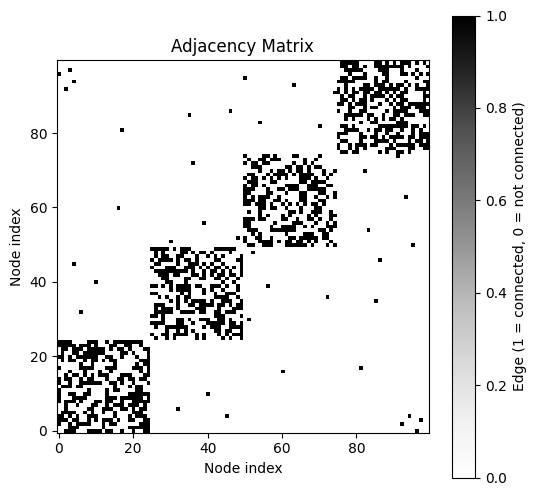

In [26]:
sizes = [25, 25, 25,25]  # sizes of 3 clusters
p_intra = 0.5           # intra-cluster connection probability
p_inter = 0.005          # inter-cluster connection probability

p = [
    [p_intra, p_inter, p_inter,p_inter],
    [p_inter, p_intra, p_inter,p_inter],
    [p_inter, p_inter, p_intra,p_inter],
    [p_inter, p_inter, p_inter,p_intra]
]

G = nx.stochastic_block_model(sizes, p, seed=42)
# G = nx.barabasi_albert_graph(n=100, m=10)

for u, v in G.edges():
    G[u][v]['weight'] = 1
#np.random.uniform(0.1, 1.0)  # random float in [0.1, 1.0]
G = assign_node_features(G)
A = nx.adjacency_matrix(G)
A = A.toarray()
plt.figure(figsize=(6, 6))
plt.imshow(A, cmap='Greys', origin='lower')  # or 'binary', 'viridis'
plt.title("Adjacency Matrix")
plt.xlabel("Node index")
plt.ylabel("Node index")
plt.colorbar(label="Edge (1 = connected, 0 = not connected)")
plt.show()


In [9]:
# # get the time series data
# folder_path = r'/home/ajay/Documents/Siddharth/Pressure/pressure/1.txt'
# data = np.loadtxt(folder_path)
# t = data[:, 0] 
# p = data[:, 1] * 1000 #any normalizing factor?

# from ts2vg import NaturalVG
# def give_visibility_network_python(p):
#     l = p.shape[0] # this gets the number of rows of the column matrix of p
#     A = np.zeros((l,l))
#     vg = NaturalVG()
#     vg.build(p)
#     A = vg.adjacency_matrix()
#     return A

# plt.plot(p[:1000])

# A = give_visibility_network_python(p[:1000])

# plt.figure(figsize=(6, 6))
# plt.imshow(A, cmap='Greys', origin='lower')  # or 'binary', 'viridis'
# plt.title("Adjacency Matrix")
# plt.xlabel("Node index")
# plt.ylabel("Node index")
# plt.colorbar(label="Edge (1 = connected, 0 = not connected)")
# plt.show()


# # # Construct recurrence network
# # RN = RecurrenceNetwork(
# #     time_series=p,
# #     dim=3,          # Embedding dimension
# #     tau=3,         # Delay
# #     recurrence_rate=0.05   # 5% recurrence rate
# # )

# # # NetworkX graph
# # G = RN.graph

# # # Adjacency matrix
# # A = RN.adjacency


# # plt.figure(figsize=(6, 6))
# # plt.imshow(A, cmap="binary", origin="lower", interpolation="nearest")
# # plt.colorbar(label="Edge")
# # plt.title("Recurrence Network Adjacency Matrix")
# # plt.xlabel("Node index")
# # plt.ylabel("Node index")
# # plt.tight_layout()
# # plt.show()

# # print("Nodes:", G.number_of_nodes())
# # print("Edges:", G.number_of_edges())

# num_nodes = len(A)
# G=nx.empty_graph(num_nodes)
# for i in range (num_nodes):
#     for j in range(i,num_nodes):
#         print(j)
#         if A[i][j] != 0 :
#             G.add_edge(i,j, weight = 1)

# G = assign_node_features(G)
# A = nx.adjacency_matrix(G)
# A = A.toarray()
# plt.figure(figsize=(6, 6))
# plt.imshow(A, cmap='Greys', origin='lower')  # or 'binary', 'viridis'
# plt.title("Adjacency Matrix")
# plt.xlabel("Node index")
# plt.ylabel("Node index")
# plt.colorbar(label="Edge (1 = connected, 0 = not connected)")
# plt.show()



In [ ]:
# Training for initialization

def print_gradients(model, name):
    print(f"\n{name} gradients:")
    for n, p in model.named_parameters():
        if p.grad is None:
            print(f"{n}: None")
        else:
            print(f"{n}: {p.grad.abs().mean().item():.6f}")
def visualize_models(loss, models, filename="model_graph"):
    """
    loss : final loss tensor
    models : dict of model_name -> model
    """

    params = {}
    for name, model in models.items():
        for p_name, p in model.named_parameters():
            params[f"{name}.{p_name}"] = p

    dot = make_dot(loss, params=params)
    dot.render(filename, format="png")

    print(f"Graph saved as {filename}.png")
def print_models(models):
    for name, model in models.items():
        print("\n" + "="*60)
        print(f"{name} Model")
        print("="*60)
        print(model)

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\nTotal params: {total_params:,}")
        print(f"Trainable params: {trainable_params:,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_epochs = 2000
feature_dim = len(G.nodes[70]["x"])
latent_dim = 12
K = 4

model_KhopNodefeatures = KhopNodefeatures(feature_dim, K).to(device)
model_NodeLatentEncoder = NodeLatentEncoder(K, feature_dim, latent_dim, latent_dim, 2).to(device)
model_edges = Empirical_Prob_edges(latent_dim, latent_dim).to(device)

optimizer = optim.Adam(list(model_KhopNodefeatures.parameters()) + list(model_NodeLatentEncoder.parameters()) + list(model_edges.parameters()), lr=1e-3)

print_models({
    "Khop": model_KhopNodefeatures,
    "Encoder": model_NodeLatentEncoder,
    "Edges": model_edges
})

node_list = list(G.nodes())
num_nodes = G.number_of_nodes()

neigh_list = []
for i in range(num_nodes):
    neigh_list.append(list(G.neighbors(i)))

features = []
for n in node_list:
    features.append(G.nodes[n]["x"])

X = torch.tensor(np.array(features), dtype=torch.float32, device=device)

loss_history = []
recon_history = []
kl_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad(set_to_none=True)

    H = model_KhopNodefeatures(neigh_list, X)
    mu, sigma, node_repr = model_NodeLatentEncoder(H)
    loss_val, kl_loss, recon_loss, beta = loss(G, u=mu, sigma=sigma, model_edges=model_edges, epoch=epoch)
    # N = G.number_of_nodes()
    # mu1 = mu.unsqueeze(1).expand(-1, N, -1)
    # mu2 = mu.unsqueeze(0).expand(N, -1, -1)
    # sig1 = sigma.unsqueeze(1).expand(-1, N, -1)
    # sig2 = sigma.unsqueeze(0).expand(N, -1, -1)
    # theta = model_edges(mu1, mu2, sig1, sig2)
    # P = 2.0 * torch.sigmoid(-theta)
    # P = torch.clamp(P, 1e-6, 1.0 - 1e-6)
    loss_val.backward()
    optimizer.step()
    loss_history.append(loss_val.detach().item())
    recon_history.append(recon_loss.detach().item())
    kl_history.append(kl_loss.detach().item())

    print(f"Epoch {epoch:03d} | Total: {loss_val.detach().item():.4f} | Recon: {recon_loss.detach().item():.4f} | KL: {kl_loss.detach().item():.4f} | Beta: {beta:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Total Loss")
plt.plot(recon_history, label="Reconstruction Loss")
plt.plot(kl_history, label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True)
plt.show()


Khop Model
KhopNodefeatures(
  (W): ParameterList(
      (0): Parameter containing: [torch.float32 of size 16x16]
      (1): Parameter containing: [torch.float32 of size 16x16]
      (2): Parameter containing: [torch.float32 of size 16x16]
      (3): Parameter containing: [torch.float32 of size 16x16]
  )
)

Total params: 1,280
Trainable params: 1,280

Encoder Model
NodeLatentEncoder(
  (node_transform): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
  )
  (mu_mlp): Sequential(
    (0): Linear(in_features=16, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
  )
  (logvar_mlp): Sequential(
    (0): Linear(in_features=16, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
  )
)

Total params: 1,760
Trainable params: 1,760

Edges Model
Empirical_Prob_edges(
  (mlp_mu): Sequential(
    (0): Linear(in_features=12, out_features=12, bias=True)
    (1): ReLU()
 

KeyboardInterrupt: 

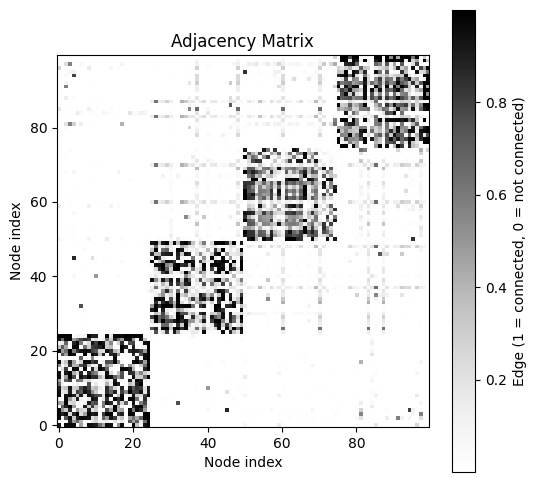

605


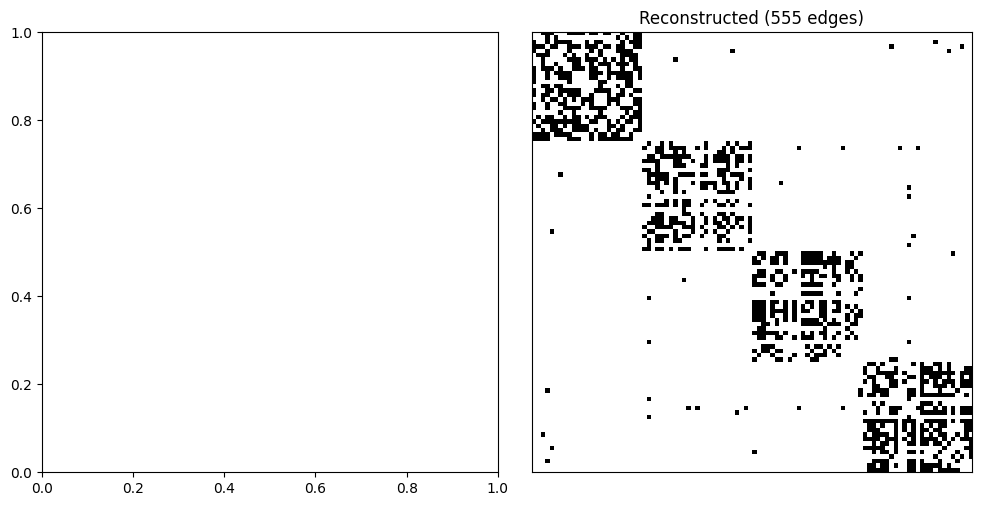

In [11]:
# Checking the reconstruction accuracy

N = G.number_of_nodes()
mu1 = mu.unsqueeze(1).expand(-1, N, -1)       # (N, N, d)
mu2 = mu.unsqueeze(0).expand(N, -1, -1)       # (N, N, d)
sig1 = sigma.unsqueeze(1).expand(-1, N, -1)     # (N, N, d)
sig2 = sigma.unsqueeze(0).expand(N, -1, -1)     # (N, N, d)
theta = model_edges(mu1, mu2, sig1, sig2) #N cross N
P = 2.0 / (1.0 + torch.exp(theta))
P = torch.clamp(P, 1e-6, 1.0 - 1e-6)

plt.figure(figsize=(6, 6))
plt.imshow(P.detach().numpy(), cmap='Greys', origin='lower')  # or 'binary', 'viridis'
plt.title("Adjacency Matrix")
plt.xlabel("Node index")
plt.ylabel("Node index")
plt.colorbar(label="Edge (1 = connected, 0 = not connected)")
plt.show()




m = G.number_of_edges()
print(m)
device = mu.device

triu = torch.triu_indices(N, N, offset=1)
edge_probs = P[triu[0], triu[1]]

# Candidate edges with probability > 0.5
candidate_idx = torch.where(edge_probs > 0.5)[0]

if candidate_idx.numel() > m:
    candidate_probs = edge_probs[candidate_idx]
    keep = torch.topk(candidate_probs, k=m).indices
    selected_idx = candidate_idx[keep]
else:
    selected_idx = candidate_idx

G_hat = nx.Graph()
G_hat.add_nodes_from(range(N))

rows = triu[0][selected_idx].cpu().numpy()
cols = triu[1][selected_idx].cpu().numpy()

G_hat.add_edges_from(zip(rows, cols))

A_hat = torch.tensor(
    nx.to_numpy_array(G_hat),
    dtype=torch.float32,
    device=device,
)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# ax[0].imshow(A.cpu().numpy(), cmap="gray_r", interpolation="nearest")
# ax[0].set_title(f"Original ({m} edges)")
# ax[0].set_xticks([])
# ax[0].set_yticks([])

ax[1].imshow(A_hat.cpu().numpy(), cmap="gray_r", interpolation="nearest")
ax[1].set_title(f"Reconstructed ({G_hat.number_of_edges()} edges)")
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

p_test
tensor(0.0006)
p
tensor(0.0006)
p_test
tensor(4.3934e-05)
p
tensor(4.3934e-05)
p_test
tensor(0.0008)
p
tensor(0.0008)
p_test
tensor(2.1038e-06)
p
tensor(2.1038e-06)
p_test
tensor(8.2108e-05)
p
tensor(8.2108e-05)
p_test
tensor(1.0607e-06)
p
tensor(1.0607e-06)
p_test
tensor(0.0008)
p
tensor(0.0008)
p_test
tensor(1.0000e-06)
p
tensor(1.0000e-06)
p_test
tensor(2.3331e-06)
p
tensor(2.3331e-06)
p_test
tensor(0.0502)
p
tensor(0.0502)
p_test
tensor(0.0006)
p
tensor(0.0006)
p_test
tensor(1.4288e-06)
p
tensor(1.4288e-06)
p_test
tensor(1.0000e-06)
p
tensor(1.0000e-06)
p_test
tensor(1.0000e-06)
p
tensor(1.0000e-06)
p_test
tensor(0.0035)
p
tensor(0.0035)
p_test
tensor(1.0000e-06)
p
tensor(1.0000e-06)
p_test
tensor(0.0038)
p
tensor(0.0038)
p_test
tensor(0.0013)
p
tensor(0.0013)
p_test
tensor(0.0007)
p
tensor(0.0007)
p_test
tensor(1.0000e-06)
p
tensor(1.0000e-06)
p_test
tensor(0.0006)
p
tensor(0.0006)
p_test
tensor(1.0000e-06)
p
tensor(1.0000e-06)
p_test
tensor(0.0017)
p
tensor(0.0017)
p_test


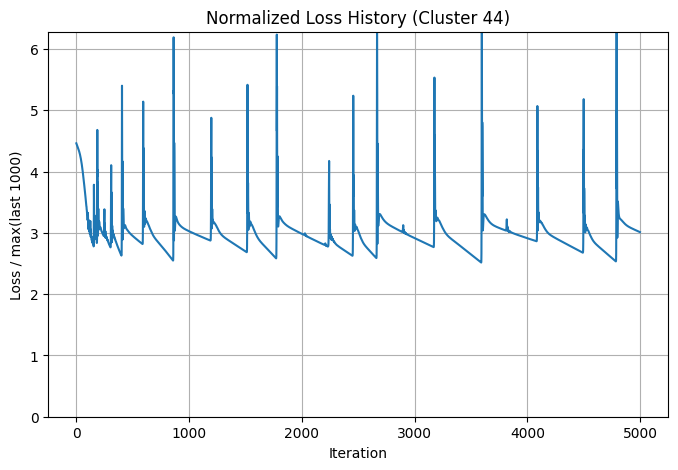

Average consecutive pairwise difference (last 1000 steps): 0.0004067156049940321
Number of supernodes 4
p_test
tensor(0.6504)
p
tensor(0.6504)
p_test
tensor(0.6456)
p
tensor(0.6456)
p_test
tensor(0.6470)
p
tensor(0.6470)
p_test
tensor(0.6407)
p
tensor(0.6407)
p_test
tensor(0.6464)
p
tensor(0.6464)
p_test
tensor(0.6392)
p
tensor(0.6392)
p_test
tensor(0.6432)
p
tensor(0.6432)
p_test
tensor(0.6388)
p
tensor(0.6388)
p_test
tensor(0.6426)
p
tensor(0.6426)
p_test
tensor(0.6417)
p
tensor(0.6417)
p_test
tensor(0.6426)
p
tensor(0.6426)
p_test
tensor(0.6486)
p
tensor(0.6486)
p_test
tensor(0.6458)
p
tensor(0.6458)
p_test
tensor(0.6429)
p
tensor(0.6429)
p_test
tensor(0.6401)
p
tensor(0.6401)
p_test
tensor(0.6418)
p
tensor(0.6418)
p_test
tensor(0.6460)
p
tensor(0.6460)
p_test
tensor(0.6489)
p
tensor(0.6489)
p_test
tensor(0.6427)
p
tensor(0.6427)
p_test
tensor(0.6452)
p
tensor(0.6452)
p_test
tensor(0.6466)
p
tensor(0.6466)
p_test
tensor(0.6439)
p
tensor(0.6439)
p_test
tensor(0.6405)
p
tensor(0.6405)

KeyboardInterrupt: 

In [29]:
Eff_interac_bookkeep = [
    {
        "children_nodes": [i],
        "update_level": 0,
        "Eff_interac_model_name": "model_edges"
    }
    for i in range(G.number_of_nodes())
]

Eff_interac_library = {f"model_edges": freeze_model(model_edges)}


rg_iterations = 10

G_all = [G]
mu_all = [mu.detach()]  
sig_all = [sigma.detach()]
coarse_all = [list(range(G.number_of_nodes()))]
N = G.number_of_nodes()
mu1 = mu.unsqueeze(1).expand(-1, N, -1)       # (N, N, d)
mu2 = mu.unsqueeze(0).expand(N, -1, -1)       # (N, N, d)
sig1 = sigma.unsqueeze(1).expand(-1, N, -1)     # (N, N, d)
sig2 = sigma.unsqueeze(0).expand(N, -1, -1)     # (N, N, d)
theta = model_edges(mu1, mu2, sig1, sig2) #N cross N
P = 2.0 * torch.sigmoid(-theta)
P = torch.clamp(P, 1e-6, 1.0 - 1e-6)
P_all = [P.detach()]



for i in range(1, rg_iterations + 1):
    G_new, Coarse_Id, Mu, Sig, num_supernodes = Renormalization(G_all[-1], mu_all[-1], sig_all[-1], i, 30) 
    G_all.append(G_new)
    coarse_all.append(Coarse_Id)
    mu_all.append(Mu.detach())
    sig_all.append(Sig.detach())
    Eff_interac_bookkeep, Eff_interac_library, p1 = train(num_supernodes, G_all[-2], G_all[-1], mu_all[-2], mu_all[-1], sig_all[-2], sig_all[-1], Eff_interac_bookkeep, Eff_interac_library, coarse_all[-1], i,P_all[-1])
    P_all.append(p1.detach())

    # Check RAM after each RG iteration
    process = psutil.Process(os.getpid())
    print(f"Iteration {i}: RAM = {process.memory_info().rss / 1024**3:.2f} GB")


In [ ]:
print(Eff_interac_bookkeep)

[{'children_nodes': [0], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [2], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [3], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [4], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [8], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [np.int64(8), 1, np.int64(5), np.int64(7)], 'update_level': 3, 'Eff_interac_model_name': 'Effective_Prob_edges_3_0'}, {'children_nodes': [11], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [17], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [18], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [19], 'update_level': 0, 'Eff_interac_model_name': 'model_edges'}, {'children_nodes': [np.int64(16), np.int64(18), 5], 'update_level': 2, 'Eff_interac_model_nam

In [29]:
print(Eff_interac_library)

{'model_edges': Empirical_Prob_edges(
  (mlp_mu): Sequential(
    (0): Linear(in_features=12, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=12, bias=True)
  )
  (mlp_sigma): Sequential(
    (0): Linear(in_features=12, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=12, bias=True)
  )
  (mlp_score): Sequential(
    (0): Linear(in_features=24, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=1, bias=True)
  )
), 'Effective_Prob_edges_1_0': Effective_Prob_edges(
  (mlp_mu): Sequential(
    (0): Linear(in_features=12, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): ReLU()
    (4):

In [ ]:
# Eff_interac_bookkeep = [
#     {
#         "children_nodes": [i],
#         "update_level": 0,
#         "Eff_interac_model_name": "model_edges"
#     }
#     for i in range(G.number_of_nodes())
# ]


# num_epochs = 5
# learning_rate = 1e-1
# loss_threshold = 0.5
# rg_iterations = 1

# optimizer = torch.optim.Adam(
#     list(model_KhopNodefeatures.parameters()) +
#     list(model_NodeLatentEncoder.parameters()) +
#     list(model_edges.parameters()),
#     lr=learning_rate
# )

# for epoch in range(num_epochs):

#     optimizer.zero_grad()
#     H = model_KhopNodefeatures(neigh_list, X)
#     mu, sigma, node_repr = model_NodeLatentEncoder(H) # sigma is the std
#     print(f"Starting epoch : {epoch}")
#     Eff_interac_library = {f"model_edges": freeze_model(model_edges)}
#     Eff_interac_library_hold = Eff_interac_library
#     Eff_interac_bookkeep_hold = Eff_interac_bookkeep
#     G_all = [G]
#     mu_all = [mu]  
#     sig_all = [sigma]
#     coarse_all = [list(range(G.number_of_nodes()))]
#     N = G.number_of_nodes()
#     mu1 = mu.unsqueeze(1).expand(-1, N, -1)       # (N, N, d)
#     mu2 = mu.unsqueeze(0).expand(N, -1, -1)       # (N, N, d)
#     sig1 = sigma.unsqueeze(1).expand(-1, N, -1)     # (N, N, d)
#     sig2 = sigma.unsqueeze(0).expand(N, -1, -1)     # (N, N, d)
#     theta = model_edges(mu1, mu2, sig1, sig2) #N cross N
#     P = 2.0 * torch.sigmoid(-theta)
#     P = torch.clamp(P, 1e-6, 1.0 - 1e-6)
#     P_all = [P]


#     for i in range(1, rg_iterations + 1):
#         n = 0
#         G_new, Coarse_Id, Mu, Sig, num_supernodes = Renormalization(G_all[-1], mu_all[-1], sig_all[-1], i, 50) 
#         if (num_supernodes != 0):
#             G_all.append(G_new)
#             coarse_all.append(Coarse_Id)
#             mu_all.append(Mu)
#             sig_all.append(Sig)
#             Eff_interac_bookkeep_hold, Eff_interac_library_hold, p1 = train(num_supernodes, G_all[-2], G_all[-1], mu_all[-2], mu_all[-1], sig_all[-2], sig_all[-1], Eff_interac_bookkeep_hold, Eff_interac_library_hold, coarse_all[-1], i)
#             optimizer.zero_grad()  
#             P_all.append(p1)
#         else:
#             n = 1
#             print(mu)
#             print(sigma)
#             plt.figure(figsize=(6, 6))
#             plt.imshow(P.detach().numpy(), cmap='Greys', origin='lower')  # or 'binary', 'viridis'
#             plt.title("Adjacency Matrix")
#             plt.xlabel("Node index")
#             plt.ylabel("Node index")
#             plt.colorbar(label="Edge (1 = connected, 0 = not connected)")
#             plt.show()

#     if (n ==1):
#         break
#     kl_loss = 0.5 * torch.sum(
#         sigma**2 + mu**2 - 1 - torch.log(sigma**2 + 1e-10)
#     ) 
#     beta = 0.0001
#     cum_loss = cumulative_epsilon_error(G_all, P_all, 0.25)
#     reg_loss = beta * kl_loss
#     loss = cum_loss + reg_loss

#     with torch.autograd.detect_anomaly():
#         loss.backward()

#     optimizer.step()
#     if epoch % 1 == 0:
#         print(
#             f"Outer Epoch {epoch:4d} | "
#             f"Cum Loss = {cum_loss.item():.6f} | "
#             f"Total = {loss.item():.6f}"
#         )

#     if loss.item() < loss_threshold:
#         print(f"Outer opt Converged at epoch {epoch}")
#         break

# # looks like the gradients are going Nan first!

Level 0
  Nodes               : 100
  Original edges      : 605
  Reconstructed edges : 605
--------------------------------------------------
Level 1
  Nodes               : 95
  Original edges      : 591
  Reconstructed edges : 591
--------------------------------------------------
Level 2
  Nodes               : 86
  Original edges      : 502
  Reconstructed edges : 502
--------------------------------------------------
Level 3
  Nodes               : 73
  Original edges      : 421
  Reconstructed edges : 421
--------------------------------------------------
Level 4
  Nodes               : 60
  Original edges      : 329
  Reconstructed edges : 329
--------------------------------------------------
Level 5
  Nodes               : 49
  Original edges      : 230
  Reconstructed edges : 230
--------------------------------------------------
Level 6
  Nodes               : 34
  Original edges      : 132
  Reconstructed edges : 132
--------------------------------------------------


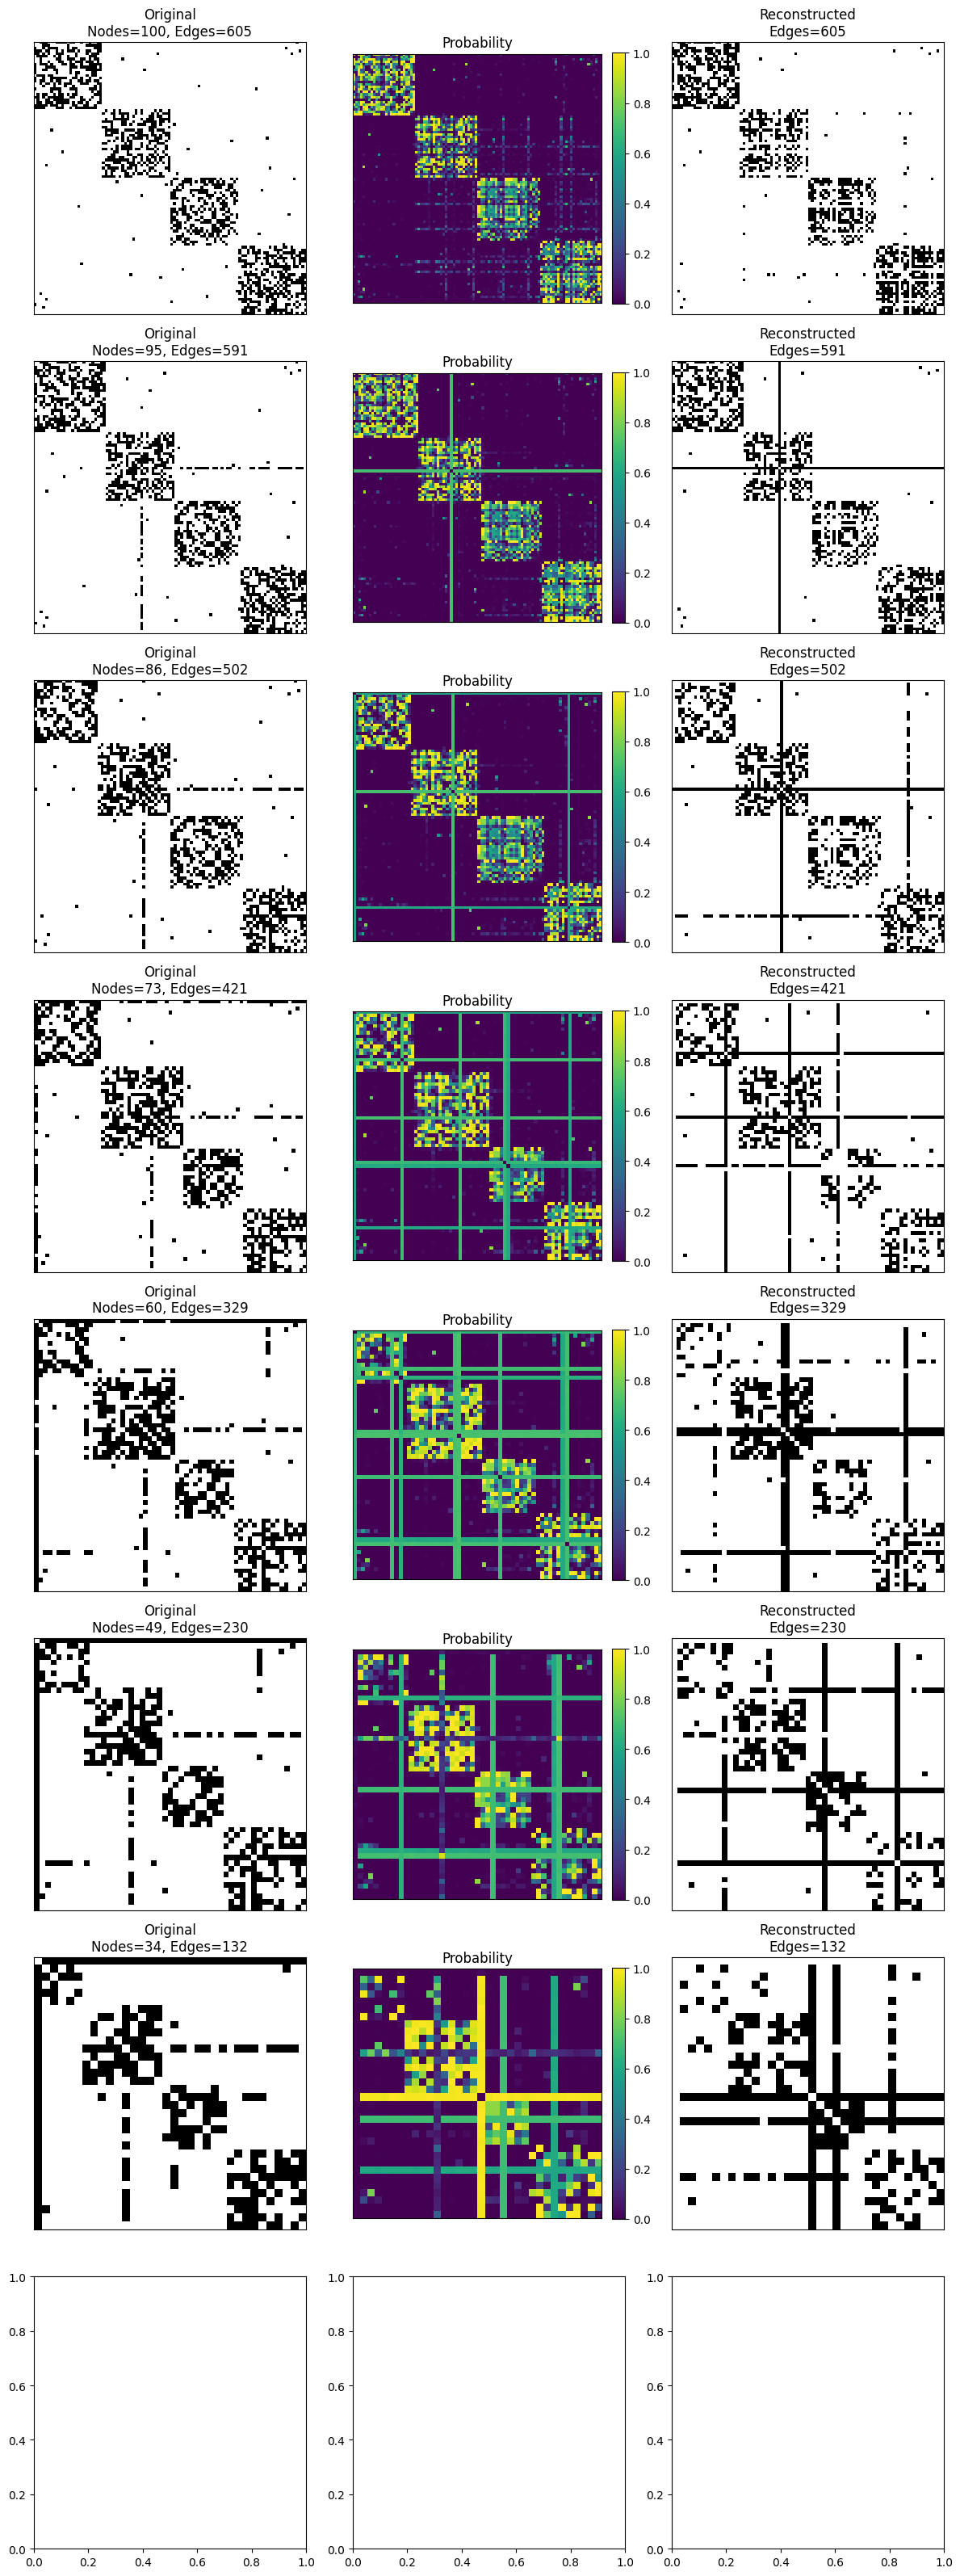

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

num_levels = len(G_all)

# Three columns:
# 1. Original adjacency
# 2. Probability matrix
# 3. Reconstructed adjacency
fig, axes = plt.subplots(num_levels, 3, figsize=(12, 4 * num_levels))

if num_levels == 1:
    axes = np.array([axes])

graph_logprob_all = []

eps = 1e-12

for level, (G, P) in enumerate(zip(G_all, P_all)):

    # -------------------------------------------------------
    # Original adjacency
    # -------------------------------------------------------
    A = nx.to_numpy_array(G)
    N = G.number_of_nodes()
    m = G.number_of_edges()

    # -------------------------------------------------------
    # Probability matrix
    # -------------------------------------------------------
    if isinstance(P, np.ndarray):
        P_torch = torch.tensor(P, dtype=torch.float32)
        P_np = P
    else:
        P_torch = P.detach().cpu()
        P_np = P_torch.numpy()

    # -------------------------------------------------------
    # Reconstruct graph with exactly m edges
    # -------------------------------------------------------
    triu = torch.triu_indices(N, N, offset=1)
    edge_probs = P_torch[triu[0], triu[1]]

        # -------------------------------------------------------
    # SBM graph log-probability
    # -------------------------------------------------------
    A_torch = torch.tensor(A, dtype=torch.float32)

    P_clamped = torch.clamp(P_torch, eps, 1 - eps)

    triu = torch.triu_indices(N, N, offset=1)

    A_upper = A_torch[triu[0], triu[1]]
    P_upper = P_clamped[triu[0], triu[1]]

    graph_logprob = torch.sum(
        A_upper * torch.log(P_upper)
        + (1.0 - A_upper) * torch.log(1.0 - P_upper)
    )

    graph_logprob_all.append(graph_logprob.item())

    candidate_idx = torch.where(edge_probs > 0.5)[0]

    if candidate_idx.numel() > m:
        candidate_probs = edge_probs[candidate_idx]
        keep = torch.topk(candidate_probs, k=m).indices
        selected_idx = candidate_idx[keep]
    else:
        # If fewer than m edges above threshold,
        # choose the globally most probable edges.
        selected_idx = torch.topk(edge_probs, k=m).indices

    rows = triu[0][selected_idx].numpy()
    cols = triu[1][selected_idx].numpy()

    G_hat = nx.Graph()
    G_hat.add_nodes_from(range(N))
    G_hat.add_edges_from(zip(rows, cols))

    A_hat = nx.to_numpy_array(G_hat)

    # -------------------------------------------------------
    # Print statistics
    # -------------------------------------------------------
    print(f"Level {level}")
    print(f"  Nodes               : {N}")
    print(f"  Original edges      : {m}")
    print(f"  Reconstructed edges : {G_hat.number_of_edges()}")
    print("-" * 50)

    # -------------------------------------------------------
    # Plot original adjacency
    # -------------------------------------------------------
    axes[level, 0].imshow(A, cmap="binary", interpolation="nearest")
    axes[level, 0].set_title(
        f"Original\nNodes={N}, Edges={m}"
    )
    axes[level, 0].set_xticks([])
    axes[level, 0].set_yticks([])

    # -------------------------------------------------------
    # Plot probability matrix
    # -------------------------------------------------------
    im = axes[level, 1].imshow(
        P_np,
        cmap="viridis",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )
    axes[level, 1].set_title("Probability")
    axes[level, 1].set_xticks([])
    axes[level, 1].set_yticks([])

    plt.colorbar(
        im,
        ax=axes[level, 1],
        fraction=0.046,
        pad=0.04
    )

    # -------------------------------------------------------
    # Plot reconstructed adjacency
    # -------------------------------------------------------
    axes[level, 2].imshow(
        A_hat,
        cmap="binary",
        interpolation="nearest"
    )
    axes[level, 2].set_title(
        f"Reconstructed\nEdges={G_hat.number_of_edges()}"
    )
    axes[level, 2].set_xticks([])
    axes[level, 2].set_yticks([])

plt.tight_layout()
plt.show()

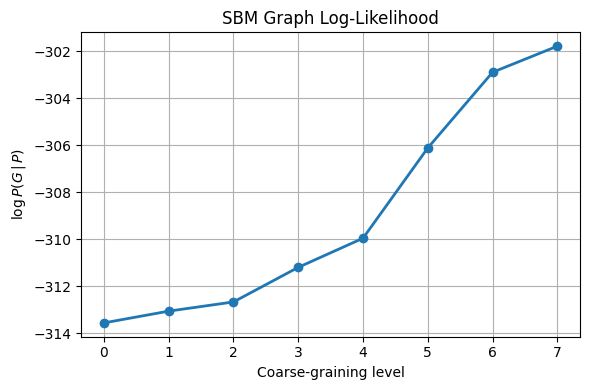

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(len(graph_logprob_all)), graph_logprob_all, "-o", linewidth=2)
plt.xlabel("Coarse-graining level")
plt.ylabel(r"$\log P(G\,|\,P)$")
plt.title("SBM Graph Log-Likelihood")
plt.grid(True)
plt.tight_layout()
plt.show()

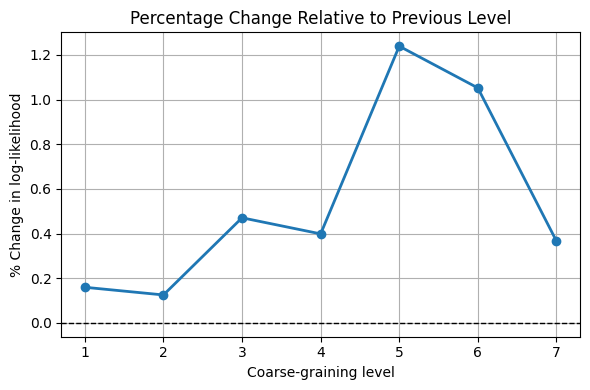

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

logprob = np.array(graph_logprob_all)

# Percentage change relative to previous level
pct_change = 100 * (logprob[1:] - logprob[:-1]) / np.abs(logprob[:-1])

levels = np.arange(1, len(logprob))

plt.figure(figsize=(6,4))
plt.plot(levels, pct_change, '-o', linewidth=2)

plt.axhline(0, color='k', linestyle='--', linewidth=1)

plt.xlabel("Coarse-graining level")
plt.ylabel("% Change in log-likelihood")
plt.title("Percentage Change Relative to Previous Level")
plt.grid(True)

plt.tight_layout()
plt.show()